<strong><center><h1> Spectral Clustering </h1></center></strong>

In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

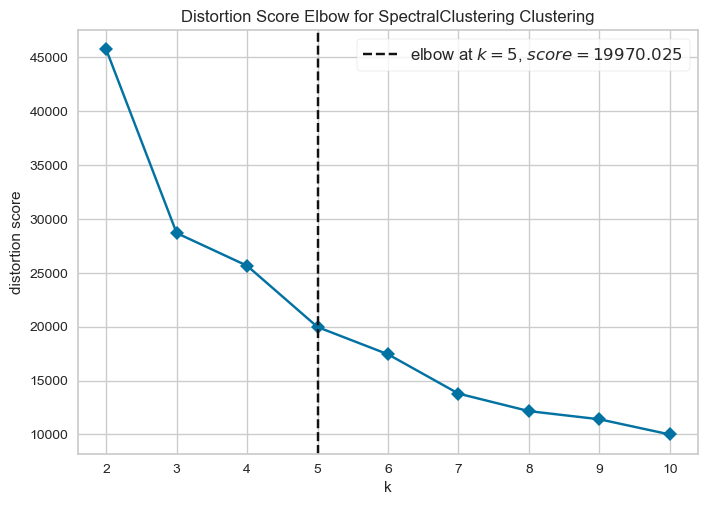

In [15]:
data_path = '../../../../data/processed_data/main_datasets/customer_data_processed.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model = SpectralClustering(affinity='nearest_neighbors', random_state=42)
visualizer = KElbowVisualizer(model, timings=False)
visualizer.fit(X_pca)
visualizer.show();

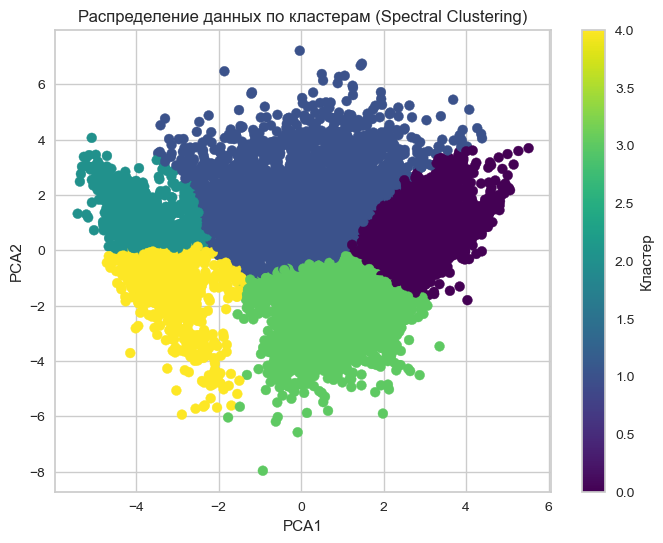

In [16]:
n_clusters = 5

spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
data['Cluster'] = spectral.fit_predict(X_pca)

data['PCA1'] = X_pca[:, 0]
data['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(data['PCA1'], data['PCA2'], c=data['Cluster'], cmap='viridis', s=50)
plt.title('Распределение данных по кластерам (Spectral Clustering)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Кластер')
plt.show()

In [17]:
output_path = '../../../../data/processed_data/train_models_data/data_with_PCA/data_without_generated_features/SpectralClustering_PCA.csv'
data.to_csv(output_path, index=False)